In [28]:
!pip install OpenCV-Python 
!pip install matplotlib

In [29]:
import cv2


img = cv2.imread('a.jpg')




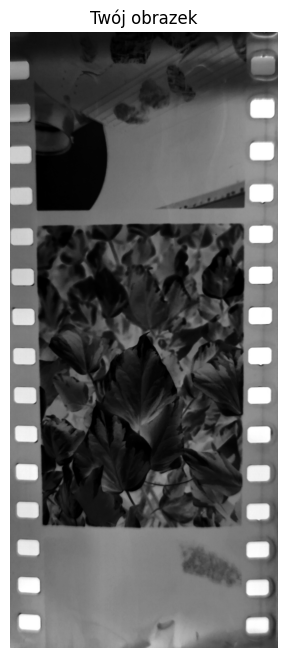

In [30]:
import cv2
import matplotlib.pyplot as plt

# 1. Wczytanie obrazka za pomocą OpenCV
img = cv2.imread('a.jpg')

# 2. Konwersja przestrzeni kolorów z BGR (OpenCV) na RGB (Matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(10, 8)) # Opcjonalna zmiana rozmiaru wyświetlanego obrazka
plt.imshow(img_rgb)
plt.axis('off')  # Ukrywa osie X i Y (przydatne przy samych zdjęciach)
plt.title('Twój obrazek') # Opcjonalny tytuł obrazka
plt.show()


In [31]:
import cv2
import numpy as np

# 1. Wczytanie jako grayscale
img = cv2.imread("a.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (img.shape[1] // 4, img.shape[0] // 4))  # Opcjonalne zmniejszenie rozmiaru dla szybszego działania


# 2. Zamiana na wektor cech (1 kolumna)
pixel_values = img.reshape((-1, 1))
pixel_values = np.float32(pixel_values)

# 3. Parametry K-means
K = 3
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10  , 1.0)
attempts = 100

# 4. K-means
_, labels, centers = cv2.kmeans(
    pixel_values,
    K,
    None,
    criteria,
    attempts,
    cv2.KMEANS_RANDOM_CENTERS
)

# 5. Rekonstrukcja obrazu
centers = np.uint8(centers)
segmented = centers[labels.flatten()]
segmented_image = segmented.reshape(img.shape)

# 6. Wyświetlenie
cv2.imshow("Original", img)
cv2.imshow("Segmented", segmented_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [32]:
# wemze centers i zrobie threashold najmniej + średnio, dzieki temu bede miec tylko otwory na bokach

white_spots, mask, dark_spots = centers[0][0], centers[1][0], centers[2][0]
print(white_spots, mask, dark_spots)
threshold = int(mask) + int((dark_spots - mask) / 2) 
print(threshold)
sprocket_img = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)[1]

sprocket_img = cv2.erode(sprocket_img, None, iterations=3)  # Opcjonalne wygładzenie krawędzi
sprocket_img = cv2.dilate(sprocket_img, None, iterations=3) # Opcjonalne wygładzenie krawędzi

cv2.imshow("Sprocket Holes", sprocket_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

119 31 235
133


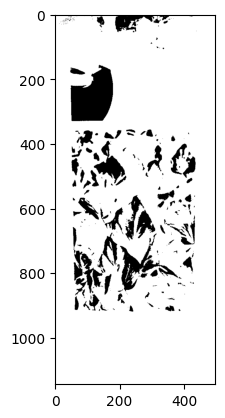

In [33]:
import matplotlib.pyplot as plt
mask_thres = int(mask) * 0.5 
mask_threasholded = cv2.threshold(img, mask_thres, 255, cv2.THRESH_BINARY)[1]

plt.imshow(mask_threasholded, cmap='gray')
plt.show()

In [34]:
import numpy as np
from itertools import combinations

def calculate_line_length_in_image(rho, theta, img_width, img_height):
    """
    Oblicza długość odcinka linii (rho, theta) mieszczącego się w prostokącie obrazu.
    """
    points = []
    
    # Przecięcie z lewą krawędzią (x = 0)
    if np.sin(theta) != 0:
        y0 = rho / np.sin(theta)
        if 0 <= y0 <= img_height:
            points.append((0, y0))
            
    # Przecięcie z prawą krawędzią (x = img_width)
    if np.sin(theta) != 0:
        y1 = (rho - img_width * np.cos(theta)) / np.sin(theta)
        if 0 <= y1 <= img_height:
            points.append((img_width, y1))
            
    # Przecięcie z górną krawędzią (y = 0)
    if np.cos(theta) != 0:
        x0 = rho / np.cos(theta)
        if 0 <= x0 <= img_width:
            points.append((x0, 0))
            
    # Przecięcie z dolną krawędzią (y = img_height)
    if np.cos(theta) != 0:
        x1 = (rho - img_height * np.sin(theta)) / np.cos(theta)
        if 0 <= x1 <= img_width:
            points.append((x1, img_height))
            
    if len(points) >= 2:
        return np.sqrt((points[0][0] - points[1][0])**2 + (points[0][1] - points[1][1])**2)
    return 0

In [ ]:
def detect_film_frame_hough(img, show_steps=True):
    """
    Wykrywa prostokąt klatki filmowej używając transformaty Hougha
    
    Args:
        img: obraz (może być w skali szarości lub kolorowy)
        show_steps: czy pokazywać etapy przetwarzania
    
    Returns:
        detected_frame: obraz z zaznaczonym prostokątem
        corners: współrzędne narożników prostokąta
    """
    
    original = img.copy()

    base_mask_value = 0    
    # Konwersja do skali szarości (jeśli obraz jest kolorowy)
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()
    

    # Redukcja szumu
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    
    # Wykrywanie krawędzi - ale tylko do pomocy dla Hougha
    edges = cv2.Canny(blurred, 70, 130, apertureSize=3)
    edges[:, :int(blurred.shape[1] * 0.05)] = 0  # Wyłącz krawędzie w lewym pasku
    edges[:, int(blurred.shape[1] * 0.95):] = 0  # Wyłącz krawędzie w prawym pasku
    edges[:int(blurred.shape[0] * 0.05), :] = 0  # Wyłącz krawędzie w górnym pasku
    edges[int(blurred.shape[0] * 0.95):, :] = 0
    

    # Transformata Hougha do wykrywania linii
    # rho: rozdzielczość w pikselach (1 piksel)
    # theta: rozdzielczość kąta (1 stopień = pi/180)
    # threshold: minimalna liczba punktów przecięcia
    lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=80)
    
    if lines is None:
        print("✗ Nie wykryto żadnych linii")
        return original, None
    
    # Filtruj linie - szukamy linii poziomych i pionowych
    horizontal_lines = []
    vertical_lines = []
    delta = np.pi / 180 * 3  # Tolerancja 3 stopnie
    
    img_height, img_width = img.shape[:2]
    min_length_ratio = 0.4  # Minimalna długość linii (60% rozmiaru obrazu)

    for line in lines:
        rho, theta = line[0]
        
        # Oblicz długość linii w obrazie
        line_length = calculate_line_length_in_image(rho, theta, img_width, img_height)
        
        # Linie poziome: theta ≈ 0° lub ≈ 180°
        if theta < np.pi/4+delta or theta > 3*np.pi/4+delta:
            # Sprawdź czy linia jest wystarczająco długa (min 60% szerokości)
            if line_length >= min_length_ratio * img_width:
                horizontal_lines.append((rho, theta))
        # Linie pionowe: theta ≈ 90°
        else:
            # Sprawdź czy linia jest wystarczająco długa (min 60% wysokości)
            if line_length >= min_length_ratio * img_height:
                vertical_lines.append((rho, theta))
    
    print(f"Znaleziono {len(horizontal_lines)} linii poziomych i {len(vertical_lines)} linii pionowych")
    
    # Filtruj podobne linie (grupowanie)
    horizontal_lines = filter_similar_lines(horizontal_lines, rho_threshold=15)
    vertical_lines = filter_similar_lines(vertical_lines, rho_threshold=15)
    
    print(f"Po filtrowaniu: {len(horizontal_lines)} poziomych i {len(vertical_lines)} pionowych")
    
    if len(horizontal_lines) < 2 or len(vertical_lines) < 2:
        print("✗ Nie znaleziono wystarczającej liczby linii do utworzenia prostokąta")
        return original, None
    
    # Znajdź przecięcia linii (narożniki)
    corners = find_rectangle_from_lines(horizontal_lines, vertical_lines, img.shape)
    
    # Przygotuj obraz do rysowania
    result = original.copy()
    if len(result.shape) == 2:
        result = cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)
    
    # Rysuj wykryte linie (opcjonalnie)
    if show_steps:
        lines_img = result.copy()
        
        # Rysuj linie poziome
        for rho, theta in horizontal_lines:
            draw_line(lines_img, rho, theta, (255, 0, 0), 2)
        
        # Rysuj linie pionowe
        for rho, theta in vertical_lines:
            draw_line(lines_img, rho, theta, (0, 0, 255), 2)
        
        cv2.imshow('Detected Lines', cv2.resize(lines_img, (800, 600)))
    
    if corners is not None:
        # Rysuj prostokąt
        corners_int = corners.astype(np.int32)
        cv2.polylines(result, [corners_int], True, (0, 255, 0), 3)
        
        # Zaznacz narożniki
        for corner in corners_int:
            cv2.circle(result, tuple(corner), 8, (255, 0, 0), -1)
        
        print("✓ Wykryto klatkę filmową!")
        print(f"Narożniki:\n{corners}")
    else:
        print("✗ Nie znaleziono prostokąta")
    
    if show_steps:
        cv2.imshow('Edges', cv2.resize(edges, (800, 600)))
        cv2.imshow('Result', cv2.resize(result, (800, 600)))
    
    return result, corners

In [41]:
def filter_similar_lines(lines, rho_threshold=20, theta_threshold=np.pi/36):
    """
    Filtruje podobne linie (grupowanie) - zostawia tylko unikalne
    """
    if not lines:
        return []
    
    filtered = []
    lines = sorted(lines, key=lambda x: x[0])  # Sortuj po rho
    
    for rho, theta in lines:
        # Sprawdź czy ta linia jest podobna do już dodanych
        is_similar = False
        for f_rho, f_theta in filtered:
            if abs(rho - f_rho) < rho_threshold and abs(theta - f_theta) < theta_threshold:
                is_similar = True
                break
        
        if not is_similar:
            filtered.append((rho, theta))
    
    return filtered


def line_intersection(line1, line2):
    """
    Oblicza punkt przecięcia dwóch linii w postaci (rho, theta)
    """
    rho1, theta1 = line1
    rho2, theta2 = line2
    
    # Macierz współczynników
    A = np.array([
        [np.cos(theta1), np.sin(theta1)],
        [np.cos(theta2), np.sin(theta2)]
    ])
    b = np.array([rho1, rho2])
    
    try:
        x, y = np.linalg.solve(A, b)
        return (x, y)
    except np.linalg.LinAlgError:
        return None


def find_rectangle_from_lines(horizontal_lines, vertical_lines, img_shape):
    """
    Znajduje prostokąt z linii poziomych i pionowych
    """
    height, width = img_shape[:2]
    
    # Sortuj linie według położenia
    horizontal_lines = sorted(horizontal_lines, key=lambda x: x[0])
    vertical_lines = sorted(vertical_lines, key=lambda x: x[0])
    
    # Dla prostokąta potrzebujemy 2 linii poziomych (góra i dół) 
    # i 2 pionowych (lewo i prawo)
    
    # Znajdź najlepszą kombinację linii tworzących prostokąt
    best_rect = None
    best_score = 0
    
    # Spróbuj różnych kombinacji
    for h_pair in combinations(range(len(horizontal_lines)), 2):
        #print(f"pozostało {len(horizontal_lines) - h_pair[1]} poziomych i {len(vertical_lines)} pionowych")
        for v_pair in combinations(range(len(vertical_lines)), 2):
            h1, h2 = horizontal_lines[h_pair[0]], horizontal_lines[h_pair[1]]
            v1, v2 = vertical_lines[v_pair[0]], vertical_lines[v_pair[1]]
            
            # Oblicz 4 narożniki
            corners = []
            for h_line in [h1, h2]:
                for v_line in [v1, v2]:
                    intersection = line_intersection(h_line, v_line)
                    if intersection is not None:
                        x, y = intersection
                        # Sprawdź czy punkt jest w granicach obrazu
                        if 0 <= x < width and 0 <= y < height:
                            corners.append([x, y])
            
            if len(corners) == 4:
                corners = np.array(corners, dtype=np.float32)
                
                # Oceń jakość prostokąta
                area = cv2.contourArea(corners)
                perimeter = cv2.arcLength(corners, True)
                
                # Prostokąt powinien mieć dużą powierzchnię
                img_area = width * height
                if area > 0.1 * img_area and area < 0.9 * img_area:
                    # Sprawdź proporcje
                    x, y, w, h = cv2.boundingRect(corners)
                    aspect_ratio = float(w) / h if h > 0 else 0
                    
                    # Oceń na podstawie powierzchni i proporcji
                    score = area
                    
                    # Preferuj proporcje 3:2 (35mm) lub 2:3
                    if 1.3 < aspect_ratio < 1.7 or 0.58 < aspect_ratio < 0.77:
                        score *= 1.5
                    
                    if score > best_score:
                        best_score = score
                        best_rect = corners
    
    # Jeśli nie znaleziono dobrego prostokąta, użyj skrajnych linii
    if best_rect is None and len(horizontal_lines) >= 2 and len(vertical_lines) >= 2:
        # Użyj pierwszej i ostatniej linii z każdej grupy
        h1, h2 = horizontal_lines[0], horizontal_lines[-1]
        v1, v2 = vertical_lines[0], vertical_lines[-1]
        
        corners = []
        for h_line in [h1, h2]:
            for v_line in [v1, v2]:
                intersection = line_intersection(h_line, v_line)
                if intersection is not None:
                    corners.append(list(intersection))
        
        if len(corners) == 4:
            best_rect = np.array(corners, dtype=np.float32)
    
    if best_rect is not None:
        # Sortuj narożniki: top-left, top-right, bottom-right, bottom-left
        best_rect = order_points(best_rect)
    
    return best_rect


def order_points(pts):
    """
    Sortuje punkty w kolejności: top-left, top-right, bottom-right, bottom-left
    """
    # Sumuj współrzędne
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    
    rect = np.zeros((4, 2), dtype=np.float32)
    
    # Top-left ma najmniejszą sumę, bottom-right największą
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    # Top-right ma najmniejszą różnicę, bottom-left największą
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    
    return rect


def draw_line(img, rho, theta, color, thickness=2):
    """
    Rysuje linię w formacie (rho, theta) na obrazie
    """
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    
    # Punkt na linii
    x1 = int(x0 + 3000 * (-b))
    y1 = int(y0 + 3000 * (a))
    x2 = int(x0 - 3000 * (-b))
    y2 = int(y0 - 3000 * (a))
    
    cv2.line(img, (x1, y1), (x2, y2), color, thickness)


def extract_and_perspective_correct(img, corners):
    """
    Wyodrębnia i koryguje perspektywę klatki filmowej
    
    Args:
        img: obraz
        corners: współrzędne 4 narożników (już posortowane)
    
    Returns:
        corrected: skorygowany obraz klatki
    """
    if corners is None:
        return None
    
    # Wymiary docelowe (standardowa proporcja 35mm: 36x24mm = 3:2)
    width = 1200
    height = 800
    
    dst_points = np.array([
        [0, 0],
        [width - 1, 0],
        [width - 1, height - 1],
        [0, height - 1]
    ], dtype=np.float32)
    
    # Oblicz macierz transformacji perspektywy
    M = cv2.getPerspectiveTransform(corners, dst_points)
    
    # Zastosuj transformację
    corrected = cv2.warpPerspective(img, M, (width, height))
    
    return corrected

In [44]:
# Uruchomienie pełnego pipeline'u detekcji klatki na zbinaryzowanej masce
# Upewniamy się, że obraz jest typu uint8 (wymagane przez operacje OpenCV)
mask_uint8 = np.uint8(mask_threasholded)

# Wywołujemy główną funkcję z włączonym pokazywaniem etapów w oknach OpenCV
result_frame, corners = detect_film_frame_hough(mask_uint8, show_steps=True)

if corners is not None:
    # Opcjonalne wyświetlenie ostatecznego wyniku z nałożonym prostokątem w matplotlib 
    plt.figure(figsize=(10, 8))
    plt.title("Wykryta klatka filmowa na masce")
    # result_frame ma domyślnie format BGR (lub GRAY, ale docelowo chcemy RGB w matplotlib)
    if len(result_frame.shape) == 3:
        plt.imshow(cv2.cvtColor(result_frame, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(result_frame, cmap='gray')
    plt.axis('off')
    plt.show()
else:
    print("Nie udało się znaleźć odpowiedniego prostokąta na tej masce.")

✗ Nie wykryto żadnych linii
Nie udało się znaleźć odpowiedniego prostokąta na tej masce.
